In [1]:
print(123)

123


In [2]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [3]:
df.count()
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
# Convert Gender to 0 and 1
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
X = df[['Gender','Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [7]:
# Step 4 - Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.cluster import KMeans

In [9]:
# Step 5 - Find best K using Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print(wcss)

[799.9999999999999, 597.9472937932278, 494.8037500130456, 395.39209034797955, 351.7432061711911, 277.3897401985191, 251.1548491119017, 211.98576294959304, 185.72807688711418, 152.0298342977569]


In [10]:
# Step 6 - Train KMeans with best K (example K=5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Step 7 - Add cluster column to dataset
df['Cluster'] = y_kmeans

print(df.value_counts())

CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
1           0       19   15                  39                      2          1
2           0       21   15                  81                      2          1
3           1       20   16                  6                       4          1
4           1       23   16                  77                      4          1
5           1       31   17                  40                      4          1
                                                                               ..
196         1       35   120                 79                      3          1
197         1       45   126                 28                      3          1
198         0       32   126                 74                      2          1
199         0       32   137                 18                      1          1
200         0       30   137                 83                      2          1
Name: count, Length: 

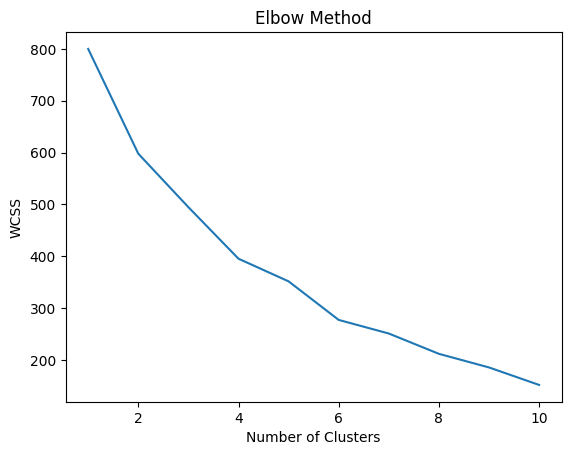

In [11]:
import matplotlib.pyplot as plt
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()